In [1]:
import pandas as pd 
import numpy as np 

In [2]:

test_beneficiary = pd.read_csv(
    r"C:\Users\sneha\Downloads\Medical Provider Fraud Detection\Test_Beneficiarydata.csv"
)

test_inpatient = pd.read_csv(
    r"C:\Users\sneha\Downloads\Medical Provider Fraud Detection\Test_Inpatientdata.csv"
)

test_outpatient = pd.read_csv(
    r"C:\Users\sneha\Downloads\Medical Provider Fraud Detection\Test_Outpatientdata.csv"
)

test_provider = pd.read_csv(
    r"C:\Users\sneha\Downloads\Medical Provider Fraud Detection\Test.csv"
)

# Initial Data Inspection

In [3]:
datasets = {
    "Test Beneficiary": test_beneficiary,
    "Test Inpatient": test_inpatient,
    "Test Outpatient": test_outpatient,
    "Test Provider": test_provider
}

for name, df in datasets.items():
    print(f"\n{name}")
    print("Shape:", df.shape)
    print("Columns:", df.shape[1])
    print(df.head(3))


Test Beneficiary
Shape: (63968, 25)
Columns: 25
      BeneID         DOB         DOD  Gender  Race RenalDiseaseIndicator  \
0  BENE11001  1943-01-01         NaN       1     1                     0   
1  BENE11007  1940-09-01  2009-12-01       1     2                     0   
2  BENE11010  1936-07-01         NaN       2     1                     0   

   State  County  NoOfMonths_PartACov  NoOfMonths_PartBCov  ...  \
0     39     230                   12                   12  ...   
1     45     610                   12                   12  ...   
2     41      30                   12                   12  ...   

   ChronicCond_Depression  ChronicCond_Diabetes  ChronicCond_IschemicHeart  \
0                       1                     1                          1   
1                       2                     1                          2   
2                       2                     1                          1   

   ChronicCond_Osteoporasis  ChronicCond_rheumatoidarthritis  \


In [4]:
for name, df in datasets.items():
    print(f"\n{'='*60}")
    print(name)
    print(f"{'='*60}")
    print(df.info())


Test Beneficiary
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63968 entries, 0 to 63967
Data columns (total 25 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   BeneID                           63968 non-null  object
 1   DOB                              63968 non-null  object
 2   DOD                              574 non-null    object
 3   Gender                           63968 non-null  int64 
 4   Race                             63968 non-null  int64 
 5   RenalDiseaseIndicator            63968 non-null  object
 6   State                            63968 non-null  int64 
 7   County                           63968 non-null  int64 
 8   NoOfMonths_PartACov              63968 non-null  int64 
 9   NoOfMonths_PartBCov              63968 non-null  int64 
 10  ChronicCond_Alzheimer            63968 non-null  int64 
 11  ChronicCond_Heartfailure         63968 non-null  int64 
 12  ChronicCond_Ki

In [7]:
print(test_provider.columns.tolist())

['Provider']


In [8]:
test_data = {
    "Beneficiary": test_beneficiary,
    "Inpatient": test_inpatient,
    "Outpatient": test_outpatient,
    "Provider": test_provider
}

In [9]:
for name, df in test_data.items():
    print(f"{name}: {df.shape}")

Beneficiary: (63968, 25)
Inpatient: (9551, 30)
Outpatient: (125841, 27)
Provider: (1353, 1)


In [10]:
for name, df in test_data.items():
    print(f"\n===== {name} =====")
    display(df.head())


===== Beneficiary =====


,BeneID,DOB,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,...,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt
0,BENE11001,1943-01-01,NaN,1,1,0,39,230,12,12,...,1,1,1,2,1,1,36000,3204,60,70
1,BENE11007,1940-09-01,2009-12-01,1,2,0,45,610,12,12,...,2,1,2,1,1,2,0,0,1490,160
2,BENE11010,1936-07-01,NaN,2,1,0,41,30,12,12,...,2,1,1,1,2,2,0,0,1170,660
3,BENE11011,1914-03-01,NaN,2,2,0,1,360,12,12,...,1,1,2,2,1,1,5000,1068,250,320
4,BENE11014,1938-04-01,NaN,2,1,Y,45,780,12,12,...,1,2,1,2,2,2,21260,2136,120,100



===== Inpatient =====


,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,...,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6
0,BENE11014,CLM67387,2009-09-09,2009-09-16,PRV57070,9000,PHY317786,PHY427017,NaN,2009-09-09,...,5990,570,41071,4280,4443.0,5849.0,NaN,NaN,NaN,NaN
1,BENE11017,CLM31237,2008-12-25,2009-01-08,PRV54750,14000,PHY314656,PHY426644,NaN,2008-12-25,...,4549,29570,34831,NaN,5551.0,NaN,NaN,NaN,NaN,NaN
2,BENE11026,CLM78930,2009-12-09,2009-12-13,PRV53758,2000,PHY349495,NaN,NaN,2009-12-09,...,78650,7813,4254,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BENE11031,CLM56810,2009-06-23,2009-07-06,PRV55825,16000,PHY429538,PHY371893,NaN,2009-06-23,...,4254,41400,5849,41401,8152.0,3320.0,NaN,NaN,NaN,NaN
4,BENE11085,CLM34625,2009-01-20,2009-01-31,PRV52338,19000,PHY397161,NaN,NaN,2009-01-20,...,V6109,7242,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



===== Outpatient =====


,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,ClmDiagnosisCode_1,...,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6,DeductibleAmtPaid,ClmAdmitDiagnosisCode
0,BENE11001,CLM392397,2009-06-02,2009-06-02,PRV55962,30,PHY347633,NaN,PHY347633,V5832,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
1,BENE11001,CLM430760,2009-06-23,2009-06-23,PRV56112,30,PHY381777,NaN,PHY381777,9594,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
2,BENE11007,CLM233081,2009-03-07,2009-03-07,PRV56979,200,PHY425311,NaN,PHY425311,7248,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
3,BENE11007,CLM496381,2009-07-29,2009-07-29,PRV56573,10,PHY393253,PHY347995,NaN,58889,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,5939
4,BENE11007,CLM521391,2009-08-12,2009-08-12,PRV56573,10,PHY417685,NaN,PHY382041,V666,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN



===== Provider =====


,Provider
0,PRV51002
1,PRV51006
2,PRV51009
3,PRV51010
4,PRV51018


In [11]:
for name, df in test_data.items():
    print(f"\n{name}")
    print(df.columns.tolist())


Beneficiary
['BeneID', 'DOB', 'DOD', 'Gender', 'Race', 'RenalDiseaseIndicator', 'State', 'County', 'NoOfMonths_PartACov', 'NoOfMonths_PartBCov', 'ChronicCond_Alzheimer', 'ChronicCond_Heartfailure', 'ChronicCond_KidneyDisease', 'ChronicCond_Cancer', 'ChronicCond_ObstrPulmonary', 'ChronicCond_Depression', 'ChronicCond_Diabetes', 'ChronicCond_IschemicHeart', 'ChronicCond_Osteoporasis', 'ChronicCond_rheumatoidarthritis', 'ChronicCond_stroke', 'IPAnnualReimbursementAmt', 'IPAnnualDeductibleAmt', 'OPAnnualReimbursementAmt', 'OPAnnualDeductibleAmt']

Inpatient
['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider', 'InscClaimAmtReimbursed', 'AttendingPhysician', 'OperatingPhysician', 'OtherPhysician', 'AdmissionDt', 'ClmAdmitDiagnosisCode', 'DeductibleAmtPaid', 'DischargeDt', 'DiagnosisGroupCode', 'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3', 'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6', 'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8', 'ClmDiagnosis

In [12]:
for name, df in test_data.items():
    print(f"\n{name}")
    print(df.columns.tolist())


Beneficiary
['BeneID', 'DOB', 'DOD', 'Gender', 'Race', 'RenalDiseaseIndicator', 'State', 'County', 'NoOfMonths_PartACov', 'NoOfMonths_PartBCov', 'ChronicCond_Alzheimer', 'ChronicCond_Heartfailure', 'ChronicCond_KidneyDisease', 'ChronicCond_Cancer', 'ChronicCond_ObstrPulmonary', 'ChronicCond_Depression', 'ChronicCond_Diabetes', 'ChronicCond_IschemicHeart', 'ChronicCond_Osteoporasis', 'ChronicCond_rheumatoidarthritis', 'ChronicCond_stroke', 'IPAnnualReimbursementAmt', 'IPAnnualDeductibleAmt', 'OPAnnualReimbursementAmt', 'OPAnnualDeductibleAmt']

Inpatient
['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider', 'InscClaimAmtReimbursed', 'AttendingPhysician', 'OperatingPhysician', 'OtherPhysician', 'AdmissionDt', 'ClmAdmitDiagnosisCode', 'DeductibleAmtPaid', 'DischargeDt', 'DiagnosisGroupCode', 'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3', 'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6', 'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8', 'ClmDiagnosis

In [13]:
for name, df in test_data.items():
    print(f"\n===== {name} =====")
    print(df.dtypes)


===== Beneficiary =====
BeneID                             object
DOB                                object
DOD                                object
Gender                              int64
Race                                int64
RenalDiseaseIndicator              object
State                               int64
County                              int64
NoOfMonths_PartACov                 int64
NoOfMonths_PartBCov                 int64
ChronicCond_Alzheimer               int64
ChronicCond_Heartfailure            int64
ChronicCond_KidneyDisease           int64
ChronicCond_Cancer                  int64
ChronicCond_ObstrPulmonary          int64
ChronicCond_Depression              int64
ChronicCond_Diabetes                int64
ChronicCond_IschemicHeart           int64
ChronicCond_Osteoporasis            int64
ChronicCond_rheumatoidarthritis     int64
ChronicCond_stroke                  int64
IPAnnualReimbursementAmt            int64
IPAnnualDeductibleAmt               int64
OPAnnualR

# Data Quality Check

In [14]:
for name, df in test_data.items():
    print(f"\n===== {name} Missing Values =====")
    
    missing = pd.DataFrame({
        "Missing_Count": df.isnull().sum(),
        "Missing_Percentage": (df.isnull().mean() * 100).round(2)
    })
    
    display(
        missing[missing["Missing_Count"] > 0]
        .sort_values("Missing_Percentage", ascending=False)
    )


===== Beneficiary Missing Values =====


,Missing_Count,Missing_Percentage
DOD,63394,99.1



===== Inpatient Missing Values =====


,Missing_Count,Missing_Percentage
ClmProcedureCode_6,9551,100.00
ClmProcedureCode_5,9549,99.98
ClmProcedureCode_4,9522,99.70
ClmProcedureCode_3,9328,97.67
ClmDiagnosisCode_10,8664,90.71
OtherPhysician,8538,89.39
ClmProcedureCode_2,8297,86.87
ClmProcedureCode_1,4118,43.12
OperatingPhysician,3962,41.48
ClmDiagnosisCode_9,3238,33.90



===== Outpatient Missing Values =====


,Missing_Count,Missing_Percentage
ClmProcedureCode_6,125841,100.00
ClmProcedureCode_5,125841,100.00
ClmProcedureCode_4,125841,100.00
ClmProcedureCode_3,125839,100.00
ClmProcedureCode_2,125832,99.99
ClmProcedureCode_1,125807,99.97
ClmDiagnosisCode_10,125578,99.79
ClmDiagnosisCode_9,122278,97.17
ClmDiagnosisCode_8,120310,95.60
ClmDiagnosisCode_7,117871,93.67



===== Provider Missing Values =====


,Missing_Count,Missing_Percentage


In [15]:
for name, df in test_data.items():
    print(
        f"{name}: {df.duplicated().sum()} duplicate rows"
    )

Beneficiary: 0 duplicate rows
Inpatient: 0 duplicate rows
Outpatient: 0 duplicate rows
Provider: 0 duplicate rows


In [17]:
test_beneficiary = test_beneficiary.drop_duplicates().copy()
test_inpatient = test_inpatient.drop_duplicates().copy()
test_outpatient = test_outpatient.drop_duplicates().copy()
test_provider = test_provider.drop_duplicates().copy()

In [18]:
def clean_column_names(df):
    df = df.copy()
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
        .str.replace("-", "_")
    )
    return df


test_beneficiary = clean_column_names(test_beneficiary)
test_inpatient = clean_column_names(test_inpatient)
test_outpatient = clean_column_names(test_outpatient)
test_provider = clean_column_names(test_provider)

In [19]:
print(test_beneficiary.columns.tolist())
print(test_inpatient.columns.tolist())
print(test_outpatient.columns.tolist())
print(test_provider.columns.tolist())

['beneid', 'dob', 'dod', 'gender', 'race', 'renaldiseaseindicator', 'state', 'county', 'noofmonths_partacov', 'noofmonths_partbcov', 'chroniccond_alzheimer', 'chroniccond_heartfailure', 'chroniccond_kidneydisease', 'chroniccond_cancer', 'chroniccond_obstrpulmonary', 'chroniccond_depression', 'chroniccond_diabetes', 'chroniccond_ischemicheart', 'chroniccond_osteoporasis', 'chroniccond_rheumatoidarthritis', 'chroniccond_stroke', 'ipannualreimbursementamt', 'ipannualdeductibleamt', 'opannualreimbursementamt', 'opannualdeductibleamt']
['beneid', 'claimid', 'claimstartdt', 'claimenddt', 'provider', 'inscclaimamtreimbursed', 'attendingphysician', 'operatingphysician', 'otherphysician', 'admissiondt', 'clmadmitdiagnosiscode', 'deductibleamtpaid', 'dischargedt', 'diagnosisgroupcode', 'clmdiagnosiscode_1', 'clmdiagnosiscode_2', 'clmdiagnosiscode_3', 'clmdiagnosiscode_4', 'clmdiagnosiscode_5', 'clmdiagnosiscode_6', 'clmdiagnosiscode_7', 'clmdiagnosiscode_8', 'clmdiagnosiscode_9', 'clmdiagnosisco

# Date Conversion

In [20]:
for name, df in test_data.items():
    print(f"\n{name}")
    print([
        col for col in df.columns
        if "date" in col.lower()
        or "admit" in col.lower()
        or "discharge" in col.lower()
    ])


Beneficiary
[]

Inpatient
['ClmAdmitDiagnosisCode', 'DischargeDt']

Outpatient
['ClmAdmitDiagnosisCode']

Provider
[]


In [22]:
date_columns = {
    "beneficiary": [
        "birthdate",
        "deathdate"
    ],
    "inpatient": [
        "admitdate",
        "dischargedate"
    ],
    "outpatient": [],
    "provider": []
}

for col in date_columns["beneficiary"]:
    if col in test_beneficiary.columns:
        test_beneficiary[col] = pd.to_datetime(
            test_beneficiary[col],
            errors="coerce"
        )

for col in date_columns["inpatient"]:
    if col in test_inpatient.columns:
        test_inpatient[col] = pd.to_datetime(
            test_inpatient[col],
            errors="coerce"
        )

# Numerical Data Validation

In [24]:
for name, df in test_data.items():
    print(f"\n===== {name} Numerical Columns =====")
    
    numeric_df = df.select_dtypes(include=np.number)
    
    if numeric_df.shape[1] == 0:
        print("No numeric columns found in this dataset.")
    else:
        display(numeric_df.describe().T)


===== Beneficiary Numerical Columns =====


,count,mean,std,min,25%,50%,75%,max
Gender,63968.0,1.574053,0.494490,1.0,1.0,2.0,2.0,2.0
Race,63968.0,1.250219,0.710366,1.0,1.0,1.0,1.0,5.0
State,63968.0,26.298681,14.954124,1.0,12.0,26.0,39.0,54.0
County,63968.0,368.597893,270.243676,0.0,140.0,330.0,560.0,999.0
NoOfMonths_PartACov,63968.0,11.918850,0.967169,0.0,12.0,12.0,12.0,12.0
NoOfMonths_PartBCov,63968.0,11.928152,0.841754,0.0,12.0,12.0,12.0,12.0
ChronicCond_Alzheimer,63968.0,1.632566,0.482110,1.0,1.0,2.0,2.0,2.0
ChronicCond_Heartfailure,63968.0,1.457447,0.498190,1.0,1.0,1.0,2.0,2.0
ChronicCond_KidneyDisease,63968.0,1.639101,0.480265,1.0,1.0,2.0,2.0,2.0
ChronicCond_Cancer,63968.0,1.862556,0.344318,1.0,2.0,2.0,2.0,2.0



===== Inpatient Numerical Columns =====


,count,mean,std,min,25%,50%,75%,max
InscClaimAmtReimbursed,9551.0,10105.306251,10316.862711,0.0,4000.00,7000.0,12000.00,125000.0
DeductibleAmtPaid,9355.0,1068.000000,0.000000,1068.0,1068.00,1068.0,1068.00,1068.0
ClmProcedureCode_1,5433.0,5907.846310,3055.573174,14.0,3891.00,5369.0,8741.00,9999.0
ClmProcedureCode_2,1254.0,4141.271930,2047.600995,42.0,2749.00,4019.0,4439.00,9998.0
ClmProcedureCode_3,223.0,4159.206278,2158.192869,185.0,2724.00,4019.0,5119.00,9984.0
ClmProcedureCode_4,29.0,4509.931034,2571.379659,260.0,3320.00,4263.0,5781.00,9971.0
ClmProcedureCode_5,2.0,7055.500000,4124.553855,4139.0,5597.25,7055.5,8513.75,9972.0
ClmProcedureCode_6,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN



===== Outpatient Numerical Columns =====


,count,mean,std,min,25%,50%,75%,max
InscClaimAmtReimbursed,125841.0,288.820496,751.028751,0.0,40.00,80.0,200.00,93240.0
ClmProcedureCode_1,34.0,5519.441176,3449.515154,61.0,3734.50,5356.0,8807.25,9904.0
ClmProcedureCode_2,9.0,3793.000000,989.062561,2724.0,2761.00,4011.0,4019.00,5849.0
ClmProcedureCode_3,2.0,6747.500000,1638.366412,5589.0,6168.25,6747.5,7326.75,7906.0
ClmProcedureCode_4,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ClmProcedureCode_5,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ClmProcedureCode_6,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DeductibleAmtPaid,125841.0,2.791181,16.039935,0.0,0.00,0.0,0.00,897.0



===== Provider Numerical Columns =====
No numeric columns found in this dataset.


In [26]:
for name, df in test_data.items():
    numeric_cols = df.select_dtypes(include=np.number).columns
    
    print(f"\n{name}")
    
    for col in numeric_cols:
        negative_count = (df[col] < 0).sum()
        
        if negative_count > 0:
            print(f"{col}: {negative_count} negative values")


Beneficiary
IPAnnualReimbursementAmt: 9 negative values
OPAnnualReimbursementAmt: 2 negative values

Inpatient

Outpatient

Provider


# Inpatient Feature Engineering

In [31]:
test_inpatient["admissiondt"] = pd.to_datetime(
    test_inpatient["admissiondt"],
    errors="coerce"
)

test_inpatient["dischargedt"] = pd.to_datetime(
    test_inpatient["dischargedt"],
    errors="coerce"
)

test_inpatient["length_of_stay"] = (
    test_inpatient["dischargedt"] -
    test_inpatient["admissiondt"]
).dt.days

In [32]:
test_inpatient["length_of_stay"].describe()

count    9551.000000
mean        5.776568
std         5.826400
min         0.000000
25%         2.000000
50%         4.000000
75%         7.000000
max        35.000000
Name: length_of_stay, dtype: float64

In [33]:
print(
    "Missing Length of Stay:",
    test_inpatient["length_of_stay"].isna().sum()
)

print(
    "Invalid Length of Stay:",
    (test_inpatient["length_of_stay"] < 0).sum()
)

print(
    "Same-day stays:",
    (test_inpatient["length_of_stay"] == 0).sum()
)

Missing Length of Stay: 0
Invalid Length of Stay: 0
Same-day stays: 151


# Beneficiary Age

In [35]:
if "birthdate" in test_beneficiary.columns:
    test_beneficiary["birth_year"] = (
        test_beneficiary["birthdate"].dt.year
    )

# Claim Amount Analysis

In [36]:
for col in test_inpatient.columns:
    if any(word in col.lower() for word in ["payment", "reimbursement", "claim", "amount"]):
        print(col)

claimid
claimstartdt
claimenddt
inscclaimamtreimbursed


In [37]:
amount_cols = test_inpatient.select_dtypes(include=np.number).columns

display(
    test_inpatient[amount_cols].describe().T
)

,count,mean,std,min,25%,50%,75%,max
inscclaimamtreimbursed,9551.0,10105.306251,10316.862711,0.0,4000.00,7000.0,12000.00,125000.0
deductibleamtpaid,9355.0,1068.000000,0.000000,1068.0,1068.00,1068.0,1068.00,1068.0
clmprocedurecode_1,5433.0,5907.846310,3055.573174,14.0,3891.00,5369.0,8741.00,9999.0
clmprocedurecode_2,1254.0,4141.271930,2047.600995,42.0,2749.00,4019.0,4439.00,9998.0
clmprocedurecode_3,223.0,4159.206278,2158.192869,185.0,2724.00,4019.0,5119.00,9984.0
clmprocedurecode_4,29.0,4509.931034,2571.379659,260.0,3320.00,4263.0,5781.00,9971.0
clmprocedurecode_5,2.0,7055.500000,4124.553855,4139.0,5597.25,7055.5,8513.75,9972.0
clmprocedurecode_6,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
length_of_stay,9551.0,5.776568,5.826400,0.0,2.00,4.0,7.00,35.0


In [38]:
amount_cols_out = test_outpatient.select_dtypes(include=np.number).columns

display(
    test_outpatient[amount_cols_out].describe().T
)

,count,mean,std,min,25%,50%,75%,max
inscclaimamtreimbursed,125841.0,288.820496,751.028751,0.0,40.00,80.0,200.00,93240.0
clmprocedurecode_1,34.0,5519.441176,3449.515154,61.0,3734.50,5356.0,8807.25,9904.0
clmprocedurecode_2,9.0,3793.000000,989.062561,2724.0,2761.00,4011.0,4019.00,5849.0
clmprocedurecode_3,2.0,6747.500000,1638.366412,5589.0,6168.25,6747.5,7326.75,7906.0
clmprocedurecode_4,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
clmprocedurecode_5,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
clmprocedurecode_6,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
deductibleamtpaid,125841.0,2.791181,16.039935,0.0,0.00,0.0,0.00,897.0


# EDA — Provider Distribution

In [40]:
inpatient_provider_claims = (
    test_inpatient.groupby("provider")
    .size()
    .reset_index(name="inpatient_claims")
)

outpatient_provider_claims = (
    test_outpatient.groupby("provider")
    .size()
    .reset_index(name="outpatient_claims")
)

In [41]:
provider_claims = pd.merge(
    inpatient_provider_claims,
    outpatient_provider_claims,
    on="provider",
    how="outer"
).fillna(0)

provider_claims["total_claims"] = (
    provider_claims["inpatient_claims"] +
    provider_claims["outpatient_claims"]
)

provider_claims = provider_claims.sort_values(
    "total_claims",
    ascending=False
)

In [42]:
provider_claims.head(20)

,provider,inpatient_claims,outpatient_claims,total_claims
439,PRV56573,185.0,3065.0,3250.0
625,PRV52080,0.0,3036.0,3036.0
199,PRV53105,216.0,2763.0,2979.0
1058,PRV55485,0.0,2823.0,2823.0
612,PRV51939,0.0,1804.0,1804.0
257,PRV54094,15.0,1691.0,1706.0
1209,PRV56678,0.0,1674.0,1674.0
282,PRV54650,8.0,1650.0,1658.0
295,PRV54751,131.0,1521.0,1652.0
130,PRV52338,152.0,1399.0,1551.0


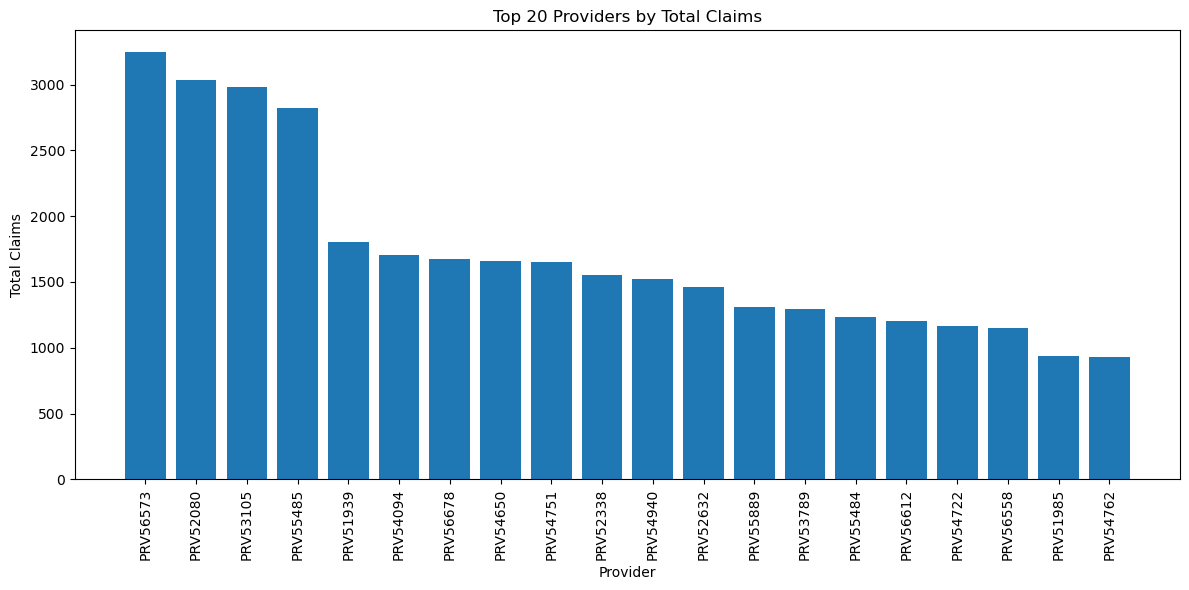

In [44]:
import matplotlib.pyplot as plt

top20 = provider_claims.head(20)

plt.figure(figsize=(12, 6))

plt.bar(
    top20["provider"].astype(str),
    top20["total_claims"]
)

plt.xticks(rotation=90)
plt.xlabel("Provider")
plt.ylabel("Total Claims")
plt.title("Top 20 Providers by Total Claims")
plt.tight_layout()
plt.show()

# Inpatient vs Outpatient Claims

In [45]:
claim_type = pd.DataFrame({
    "Claim_Type": ["Inpatient", "Outpatient"],
    "Claims": [
        len(test_inpatient),
        len(test_outpatient)
    ]
})

display(claim_type)

,Claim_Type,Claims
0,Inpatient,9551
1,Outpatient,125841


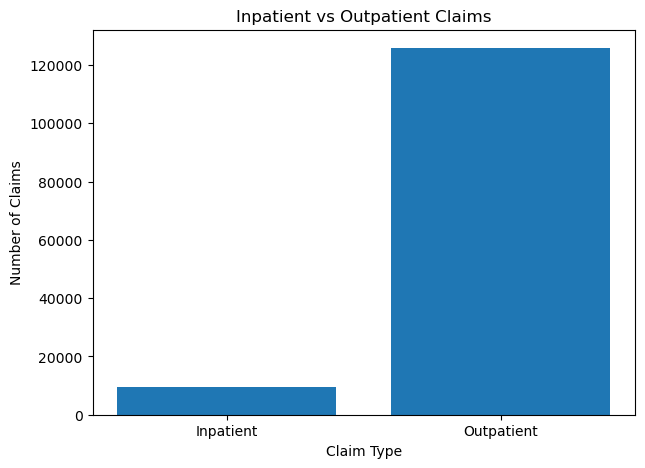

In [46]:
plt.figure(figsize=(7, 5))

plt.bar(
    claim_type["Claim_Type"],
    claim_type["Claims"]
)

plt.xlabel("Claim Type")
plt.ylabel("Number of Claims")
plt.title("Inpatient vs Outpatient Claims")

plt.show()

# Top Diagnosis Analysis

In [47]:
diagnosis_cols = [
    col for col in test_inpatient.columns
    if "diagnosis" in col.lower()
]

print(diagnosis_cols)

['clmadmitdiagnosiscode', 'diagnosisgroupcode', 'clmdiagnosiscode_1', 'clmdiagnosiscode_2', 'clmdiagnosiscode_3', 'clmdiagnosiscode_4', 'clmdiagnosiscode_5', 'clmdiagnosiscode_6', 'clmdiagnosiscode_7', 'clmdiagnosiscode_8', 'clmdiagnosiscode_9', 'clmdiagnosiscode_10']


In [48]:
if "clmdiagnosiscode_1" in test_inpatient.columns:
    
    top_diagnoses = (
        test_inpatient["clmdiagnosiscode_1"]
        .value_counts()
        .head(15)
    )
    
    display(top_diagnoses)

clmdiagnosiscode_1
486      352
V5789    291
0389     263
49121    237
41401    235
42731    219
4280     195
5990     183
43491    165
41071    149
71536    143
5849     143
78659    112
5070      98
7802      94
Name: count, dtype: int64

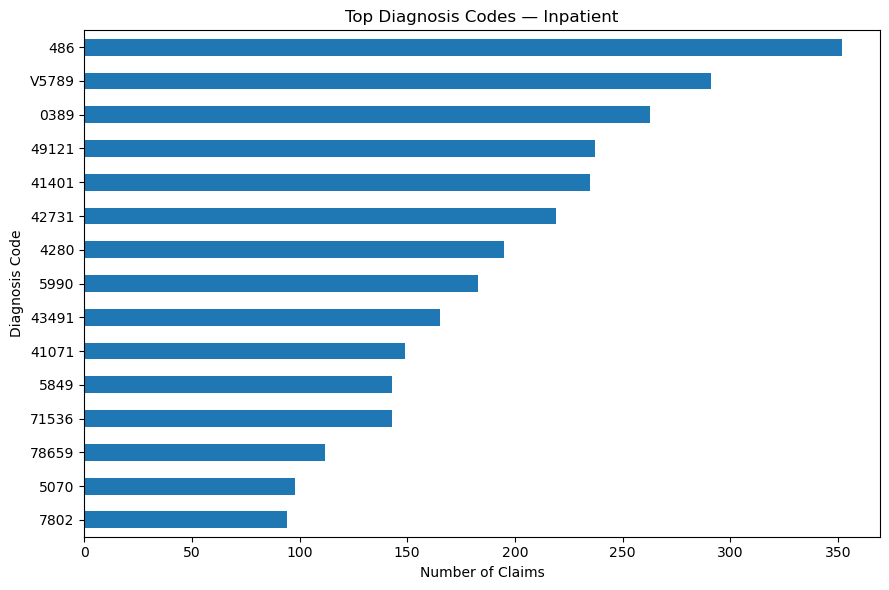

In [49]:
top_diagnoses.sort_values().plot(
    kind="barh",
    figsize=(9, 6)
)

plt.xlabel("Number of Claims")
plt.ylabel("Diagnosis Code")
plt.title("Top Diagnosis Codes — Inpatient")
plt.tight_layout()
plt.show()

# High-Cost Provider Analysis

In [55]:
provider_risk = (
    test_inpatient
    .groupby("provider")
    .agg(
        claim_count=("provider", "size"),
        total_reimbursement=(
            "inscclaimamtreimbursed",
            "sum"
        ),
        avg_reimbursement=(
            "inscclaimamtreimbursed",
            "mean"
        )
    )
    .reset_index()
)

provider_risk.head()

,provider,claim_count,total_reimbursement,avg_reimbursement
0,PRV51009,2,15000,7500.000000
1,PRV51010,6,56000,9333.333333
2,PRV51020,2,16000,8000.000000
3,PRV51022,7,105000,15000.000000
4,PRV51033,1,2000,2000.000000


In [56]:
provider_risk = (
    test_inpatient
    .groupby("provider")
    .agg(
        claim_count=("provider", "size"),
        total_reimbursement=(
            "inscclaimamtreimbursed",
            "sum"
        ),
        avg_reimbursement=(
            "inscclaimamtreimbursed",
            "mean"
        )
    )
    .reset_index()
)

provider_risk.head()

,provider,claim_count,total_reimbursement,avg_reimbursement
0,PRV51009,2,15000,7500.000000
1,PRV51010,6,56000,9333.333333
2,PRV51020,2,16000,8000.000000
3,PRV51022,7,105000,15000.000000
4,PRV51033,1,2000,2000.000000


In [57]:
provider_risk["claim_volume_score"] = (
    provider_risk["claim_count"].rank(pct=True) * 100
)

provider_risk["reimbursement_score"] = (
    provider_risk["total_reimbursement"].rank(pct=True) * 100
)

provider_risk["avg_claim_score"] = (
    provider_risk["avg_reimbursement"].rank(pct=True) * 100
)

In [58]:
provider_risk["risk_score"] = (
    provider_risk["claim_volume_score"] * 0.30 +
    provider_risk["reimbursement_score"] * 0.40 +
    provider_risk["avg_claim_score"] * 0.30
)

In [59]:
provider_risk = provider_risk.sort_values(
    "risk_score",
    ascending=False
)

display(provider_risk.head(20))

,provider,claim_count,total_reimbursement,avg_reimbursement,claim_volume_score,reimbursement_score,avg_claim_score,risk_score
313,PRV54948,116,1401000,12077.586207,97.307692,97.884615,79.615385,92.230769
296,PRV54766,139,1573000,11316.546763,98.461538,98.653846,74.038462,91.211538
429,PRV56460,154,1712400,11119.480519,98.846154,99.038462,72.884615,91.134615
369,PRV55478,126,1436900,11403.968254,97.692308,98.076923,74.615385,90.923077
166,PRV52840,48,609000,12687.500000,93.557692,94.615385,82.500000,90.663462
317,PRV54958,49,608000,12408.163265,93.942308,94.423077,81.538462,90.413462
439,PRV56573,185,1975040,10675.891892,99.230769,99.230769,68.269231,89.942308
393,PRV55845,45,551700,12260.000000,92.788462,94.038462,80.769231,89.682692
8,PRV51073,90,1016800,11297.777778,96.346154,96.346154,73.846154,89.596154
213,PRV53366,44,541500,12306.818182,92.500000,93.846154,80.961538,89.576923


# Risk Classification

In [60]:
provider_risk["risk_category"] = pd.cut(
    provider_risk["risk_score"],
    bins=[-1, 50, 75, 90, 100],
    labels=[
        "Low",
        "Medium",
        "High",
        "Critical"
    ]
)

In [61]:
provider_risk["risk_category"].value_counts()

risk_category
Low         247
Medium      174
High         93
Critical      6
Name: count, dtype: int64

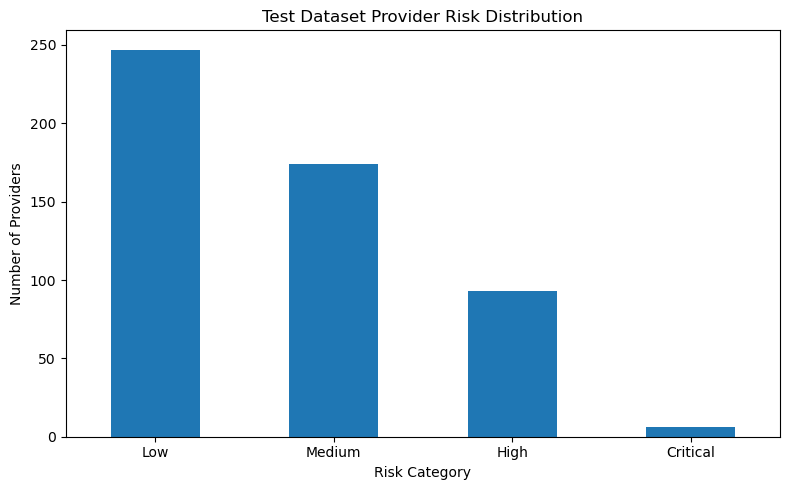

In [62]:
risk_counts = (
    provider_risk["risk_category"]
    .value_counts()
    .sort_index()
)

risk_counts.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Risk Category")
plt.ylabel("Number of Providers")
plt.title("Test Dataset Provider Risk Distribution")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Train vs Test Comparison

In [63]:
comparison = pd.DataFrame({
    "Metric": [
        "Beneficiaries",
        "Inpatient Claims",
        "Outpatient Claims",
        "Providers"
    ],
    "Test": [
        len(test_beneficiary),
        len(test_inpatient),
        len(test_outpatient),
        test_provider["provider"].nunique()
        if "provider" in test_provider.columns else np.nan
    ]
})

display(comparison)

,Metric,Test
0,Beneficiaries,63968
1,Inpatient Claims,9551
2,Outpatient Claims,125841
3,Providers,1353


# TEST DATA — FEATURE ENGINEERING

In [64]:
# Inpatient dates

inpatient_date_cols = [
    "claimstartdt",
    "claimenddt",
    "admissiondt",
    "dischargedt"
]

for col in inpatient_date_cols:
    test_inpatient[col] = pd.to_datetime(
        test_inpatient[col],
        errors="coerce"
    )

In [66]:
# Outpatient dates

print(test_outpatient.columns.tolist())

['beneid', 'claimid', 'claimstartdt', 'claimenddt', 'provider', 'inscclaimamtreimbursed', 'attendingphysician', 'operatingphysician', 'otherphysician', 'clmdiagnosiscode_1', 'clmdiagnosiscode_2', 'clmdiagnosiscode_3', 'clmdiagnosiscode_4', 'clmdiagnosiscode_5', 'clmdiagnosiscode_6', 'clmdiagnosiscode_7', 'clmdiagnosiscode_8', 'clmdiagnosiscode_9', 'clmdiagnosiscode_10', 'clmprocedurecode_1', 'clmprocedurecode_2', 'clmprocedurecode_3', 'clmprocedurecode_4', 'clmprocedurecode_5', 'clmprocedurecode_6', 'deductibleamtpaid', 'clmadmitdiagnosiscode']


In [67]:
outpatient_date_cols = [
    col for col in test_outpatient.columns
    if any(x in col.lower() for x in ["dt", "date"])
]

print(outpatient_date_cols)

['claimstartdt', 'claimenddt']


In [69]:
for col in outpatient_date_cols:
    test_outpatient[col] = pd.to_datetime(
        test_outpatient[col],
        errors="coerce"
    )

# Inpatient Length of Stay

In [70]:
test_inpatient["length_of_stay"] = (
    test_inpatient["dischargedt"] -
    test_inpatient["admissiondt"]
).dt.days

In [71]:
test_inpatient["length_of_stay"].describe()

count    9551.000000
mean        5.776568
std         5.826400
min         0.000000
25%         2.000000
50%         4.000000
75%         7.000000
max        35.000000
Name: length_of_stay, dtype: float64

In [72]:
test_inpatient["invalid_length_of_stay"] = (
    test_inpatient["length_of_stay"] < 0
).astype(int)

In [73]:
los_threshold = test_inpatient[
    "length_of_stay"
].quantile(0.95)

print("95th percentile LOS:", los_threshold)

95th percentile LOS: 17.0


In [74]:
test_inpatient["long_stay"] = (
    test_inpatient["length_of_stay"] >= los_threshold
).astype(int)

# High-Cost Inpatient Claims

In [75]:
ip_cost_threshold = test_inpatient[
    "inscclaimamtreimbursed"
].quantile(0.95)

print(
    "Inpatient high-cost threshold:",
    ip_cost_threshold
)

Inpatient high-cost threshold: 30000.0


In [76]:
test_inpatient["high_cost_claim"] = (
    test_inpatient["inscclaimamtreimbursed"]
    >= ip_cost_threshold
).astype(int)

In [77]:
print(
    "High-cost inpatient claims:",
    test_inpatient["high_cost_claim"].sum()
)

High-cost inpatient claims: 494


# High-Cost Outpatient Claims

In [78]:
op_cost_threshold = test_outpatient[
    "inscclaimamtreimbursed"
].quantile(0.95)

print(
    "Outpatient high-cost threshold:",
    op_cost_threshold
)

Outpatient high-cost threshold: 1500.0


In [79]:
test_outpatient["high_cost_claim"] = (
    test_outpatient["inscclaimamtreimbursed"]
    >= op_cost_threshold
).astype(int)

In [80]:
print(
    "High-cost outpatient claims:",
    test_outpatient["high_cost_claim"].sum()
)

High-cost outpatient claims: 6505


# Inpatient Provider-Level Features

In [82]:
ip_provider_features = (
    test_inpatient
    .groupby("provider")
    .agg(
        inpatient_claims=("claimid", "count"),

        inpatient_beneficiaries=(
            "beneid",
            "nunique"
        ),

        inpatient_total_reimbursement=(
            "inscclaimamtreimbursed",
            "sum"
        ),

        inpatient_avg_reimbursement=(
            "inscclaimamtreimbursed",
            "mean"
        ),

        inpatient_median_reimbursement=(
            "inscclaimamtreimbursed",
            "median"
        ),

        inpatient_high_cost_claims=(
            "high_cost_claim",
            "sum"
        ),

        avg_length_of_stay=(
            "length_of_stay",
            "mean"
        ),

        long_stay_claims=(
            "long_stay",
            "sum"
        )
    )
    .reset_index()
)

In [83]:
display(ip_provider_features.head())

,provider,inpatient_claims,inpatient_beneficiaries,inpatient_total_reimbursement,inpatient_avg_reimbursement,inpatient_median_reimbursement,inpatient_high_cost_claims,avg_length_of_stay,long_stay_claims
0,PRV51009,2,2,15000,7500.000000,7500.0,0,3.000000,0
1,PRV51010,6,5,56000,9333.333333,5500.0,0,3.833333,0
2,PRV51020,2,2,16000,8000.000000,8000.0,0,6.000000,0
3,PRV51022,7,7,105000,15000.000000,7000.0,2,3.428571,0
4,PRV51033,1,1,2000,2000.000000,2000.0,0,3.000000,0


# Inpatient Provider Rates

In [85]:
ip_provider_features["inpatient_high_cost_rate"] = (
    ip_provider_features["inpatient_high_cost_claims"] /
    ip_provider_features["inpatient_claims"] * 100
)

In [86]:
ip_provider_features["long_stay_rate"] = (
    ip_provider_features["long_stay_claims"] /
    ip_provider_features["inpatient_claims"] * 100
)

In [87]:
display(
    ip_provider_features[
        [
            "provider",
            "inpatient_claims",
            "inpatient_total_reimbursement",
            "inpatient_avg_reimbursement",
            "inpatient_high_cost_rate",
            "avg_length_of_stay",
            "long_stay_rate"
        ]
    ].head(20)
)

,provider,inpatient_claims,inpatient_total_reimbursement,inpatient_avg_reimbursement,inpatient_high_cost_rate,avg_length_of_stay,long_stay_rate
0,PRV51009,2,15000,7500.000000,0.000000,3.000000,0.000000
1,PRV51010,6,56000,9333.333333,0.000000,3.833333,0.000000
2,PRV51020,2,16000,8000.000000,0.000000,6.000000,0.000000
3,PRV51022,7,105000,15000.000000,28.571429,3.428571,0.000000
4,PRV51033,1,2000,2000.000000,0.000000,3.000000,0.000000
5,PRV51039,20,218000,10900.000000,10.000000,5.150000,0.000000
6,PRV51051,6,39000,6500.000000,0.000000,6.000000,0.000000
7,PRV51069,6,58000,9666.666667,16.666667,7.166667,16.666667
8,PRV51073,90,1016800,11297.777778,8.888889,5.444444,4.444444
9,PRV51079,12,102000,8500.000000,0.000000,5.166667,0.000000


# Outpatient Provider-Level Features

In [88]:
op_provider_features = (
    test_outpatient
    .groupby("provider")
    .agg(
        outpatient_claims=("claimid", "count"),

        outpatient_beneficiaries=(
            "beneid",
            "nunique"
        ),

        outpatient_total_reimbursement=(
            "inscclaimamtreimbursed",
            "sum"
        ),

        outpatient_avg_reimbursement=(
            "inscclaimamtreimbursed",
            "mean"
        ),

        outpatient_median_reimbursement=(
            "inscclaimamtreimbursed",
            "median"
        ),

        outpatient_high_cost_claims=(
            "high_cost_claim",
            "sum"
        )
    )
    .reset_index()
)

In [89]:
display(op_provider_features.head())

,provider,outpatient_claims,outpatient_beneficiaries,outpatient_total_reimbursement,outpatient_avg_reimbursement,outpatient_median_reimbursement,outpatient_high_cost_claims
0,PRV51002,205,169,53790,262.390244,80.0,8
1,PRV51006,102,81,30720,301.176471,80.0,8
2,PRV51009,37,28,12230,330.540541,80.0,2
3,PRV51010,32,22,8580,268.125000,80.0,2
4,PRV51018,190,146,61620,324.315789,80.0,11


# Outpatient High-Cost Rate

In [90]:
op_provider_features["outpatient_high_cost_rate"] = (
    op_provider_features["outpatient_high_cost_claims"] /
    op_provider_features["outpatient_claims"] * 100
)

In [91]:
display(
    op_provider_features[
        [
            "provider",
            "outpatient_claims",
            "outpatient_total_reimbursement",
            "outpatient_avg_reimbursement",
            "outpatient_high_cost_rate"
        ]
    ].head(20)
)

,provider,outpatient_claims,outpatient_total_reimbursement,outpatient_avg_reimbursement,outpatient_high_cost_rate
0,PRV51002,205,53790,262.390244,3.902439
1,PRV51006,102,30720,301.176471,7.843137
2,PRV51009,37,12230,330.540541,5.405405
3,PRV51010,32,8580,268.125000,6.250000
4,PRV51018,190,61620,324.315789,5.789474
5,PRV51019,6,3590,598.333333,16.666667
6,PRV51020,43,8110,188.604651,0.000000
7,PRV51022,117,36580,312.649573,6.837607
8,PRV51028,9,1490,165.555556,0.000000
9,PRV51033,40,5740,143.500000,0.000000


# Combine Inpatient + Outpatient Features

In [92]:
provider_features = pd.merge(
    ip_provider_features,
    op_provider_features,
    on="provider",
    how="outer"
)

In [93]:
numeric_cols = provider_features.select_dtypes(
    include=np.number
).columns

provider_features[numeric_cols] = (
    provider_features[numeric_cols]
    .fillna(0)
)

In [94]:
print(provider_features.shape)

display(provider_features.head())

(1353, 18)


,provider,inpatient_claims,inpatient_beneficiaries,inpatient_total_reimbursement,inpatient_avg_reimbursement,inpatient_median_reimbursement,inpatient_high_cost_claims,avg_length_of_stay,long_stay_claims,inpatient_high_cost_rate,long_stay_rate,outpatient_claims,outpatient_beneficiaries,outpatient_total_reimbursement,outpatient_avg_reimbursement,outpatient_median_reimbursement,outpatient_high_cost_claims,outpatient_high_cost_rate
0,PRV51009,2.0,2.0,15000.0,7500.000000,7500.0,0.0,3.000000,0.0,0.000000,0.0,37.0,28.0,12230.0,330.540541,80.0,2.0,5.405405
1,PRV51010,6.0,5.0,56000.0,9333.333333,5500.0,0.0,3.833333,0.0,0.000000,0.0,32.0,22.0,8580.0,268.125000,80.0,2.0,6.250000
2,PRV51020,2.0,2.0,16000.0,8000.000000,8000.0,0.0,6.000000,0.0,0.000000,0.0,43.0,37.0,8110.0,188.604651,90.0,0.0,0.000000
3,PRV51022,7.0,7.0,105000.0,15000.000000,7000.0,2.0,3.428571,0.0,28.571429,0.0,117.0,98.0,36580.0,312.649573,70.0,8.0,6.837607
4,PRV51033,1.0,1.0,2000.0,2000.000000,2000.0,0.0,3.000000,0.0,0.000000,0.0,40.0,40.0,5740.0,143.500000,65.0,0.0,0.000000


# Total Claim Volume

In [95]:
provider_features["total_claims"] = (
    provider_features["inpatient_claims"] +
    provider_features["outpatient_claims"]
)

In [101]:
provider_features["total_claims"]

0        39.0
1        38.0
2        45.0
3       124.0
4        41.0
        ...  
1348     11.0
1349      8.0
1350      2.0
1351     49.0
1352    105.0
Name: total_claims, Length: 1353, dtype: float64

# Total Reimbursement

In [98]:
provider_features["total_reimbursement"] = (
    provider_features["inpatient_total_reimbursement"] +
    provider_features["outpatient_total_reimbursement"]
)

In [100]:
provider_features["total_reimbursement"]

0        27230.0
1        64580.0
2        24110.0
3       141580.0
4         7740.0
          ...   
1348       860.0
1349      1590.0
1350       510.0
1351      9980.0
1352     27020.0
Name: total_reimbursement, Length: 1353, dtype: float64

# Total Unique Beneficiaries

In [99]:
ip_bene = (
    test_inpatient[
        ["provider", "beneid"]
    ]
    .drop_duplicates()
)

op_bene = (
    test_outpatient[
        ["provider", "beneid"]
    ]
    .drop_duplicates()
)

all_provider_beneficiaries = pd.concat(
    [ip_bene, op_bene]
).drop_duplicates()

In [102]:
unique_beneficiary_count = (
    all_provider_beneficiaries
    .groupby("provider")
    .size()
    .reset_index(
        name="total_unique_beneficiaries"
    )
)

In [103]:
provider_features = pd.merge(
    provider_features,
    unique_beneficiary_count,
    on="provider",
    how="left"
)

In [104]:
provider_features

,provider,inpatient_claims,inpatient_beneficiaries,inpatient_total_reimbursement,inpatient_avg_reimbursement,inpatient_median_reimbursement,inpatient_high_cost_claims,avg_length_of_stay,long_stay_claims,inpatient_high_cost_rate,...,outpatient_claims,outpatient_beneficiaries,outpatient_total_reimbursement,outpatient_avg_reimbursement,outpatient_median_reimbursement,outpatient_high_cost_claims,outpatient_high_cost_rate,total_claims,total_reimbursement,total_unique_beneficiaries
0,PRV51009,2.0,2.0,15000.0,7500.000000,7500.0,0.0,3.000000,0.0,0.000000,...,37.0,28.0,12230.0,330.540541,80.0,2.0,5.405405,39.0,27230.0,30
1,PRV51010,6.0,5.0,56000.0,9333.333333,5500.0,0.0,3.833333,0.0,0.000000,...,32.0,22.0,8580.0,268.125000,80.0,2.0,6.250000,38.0,64580.0,25
2,PRV51020,2.0,2.0,16000.0,8000.000000,8000.0,0.0,6.000000,0.0,0.000000,...,43.0,37.0,8110.0,188.604651,90.0,0.0,0.000000,45.0,24110.0,38
3,PRV51022,7.0,7.0,105000.0,15000.000000,7000.0,2.0,3.428571,0.0,28.571429,...,117.0,98.0,36580.0,312.649573,70.0,8.0,6.837607,124.0,141580.0,103
4,PRV51033,1.0,1.0,2000.0,2000.000000,2000.0,0.0,3.000000,0.0,0.000000,...,40.0,40.0,5740.0,143.500000,65.0,0.0,0.000000,41.0,7740.0,41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1348,PRV57713,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,...,11.0,10.0,860.0,78.181818,60.0,0.0,0.000000,11.0,860.0,10
1349,PRV57726,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,...,8.0,8.0,1590.0,198.750000,55.0,0.0,0.000000,8.0,1590.0,8
1350,PRV57745,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,...,2.0,2.0,510.0,255.000000,255.0,0.0,0.000000,2.0,510.0,2
1351,PRV57749,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,...,49.0,45.0,9980.0,203.673469,80.0,1.0,2.040816,49.0,9980.0,45


# Average Reimbursement Per Claim

In [105]:
provider_features["avg_reimbursement_per_claim"] = (
    provider_features["total_reimbursement"] /
    provider_features["total_claims"]
)

In [106]:
provider_features["avg_reimbursement_per_claim"]

0        698.205128
1       1699.473684
2        535.777778
3       1141.774194
4        188.780488
           ...     
1348      78.181818
1349     198.750000
1350     255.000000
1351     203.673469
1352     257.333333
Name: avg_reimbursement_per_claim, Length: 1353, dtype: float64

# Claims Per Beneficiary

In [107]:
provider_features["claims_per_beneficiary"] = (
    provider_features["total_claims"] /
    provider_features["total_unique_beneficiaries"]
)

In [108]:
provider_features["claims_per_beneficiary"]

0       1.300000
1       1.520000
2       1.184211
3       1.203883
4       1.000000
          ...   
1348    1.100000
1349    1.000000
1350    1.000000
1351    1.088889
1352    1.117021
Name: claims_per_beneficiary, Length: 1353, dtype: float64

# Reimbursement Per Beneficiary

In [109]:
provider_features["reimbursement_per_beneficiary"] = (
    provider_features["total_reimbursement"] /
    provider_features["total_unique_beneficiaries"]
)

# Inpatient Mix

In [110]:
provider_features["inpatient_claim_mix"] = (
    provider_features["inpatient_claims"] /
    provider_features["total_claims"] * 100
)

In [111]:
provider_features["outpatient_claim_mix"] = (
    provider_features["outpatient_claims"] /
    provider_features["total_claims"] * 100
)

In [112]:
display(
    provider_features[
        [
            "provider",
            "total_claims",
            "inpatient_claim_mix",
            "outpatient_claim_mix"
        ]
    ].head(20)
)

,provider,total_claims,inpatient_claim_mix,outpatient_claim_mix
0,PRV51009,39.0,5.128205,94.871795
1,PRV51010,38.0,15.789474,84.210526
2,PRV51020,45.0,4.444444,95.555556
3,PRV51022,124.0,5.645161,94.354839
4,PRV51033,41.0,2.439024,97.560976
5,PRV51039,225.0,8.888889,91.111111
6,PRV51051,362.0,1.657459,98.342541
7,PRV51069,698.0,0.859599,99.140401
8,PRV51073,143.0,62.937063,37.062937
9,PRV51079,25.0,48.000000,52.000000


# Combined High-Cost Claims

In [113]:
provider_features["total_high_cost_claims"] = (
    provider_features["inpatient_high_cost_claims"] +
    provider_features["outpatient_high_cost_claims"]
)

In [114]:
provider_features["overall_high_cost_rate"] = (
    provider_features["total_high_cost_claims"] /
    provider_features["total_claims"] * 100
)

# Reimbursement Concentration

In [116]:
provider_features["inpatient_reimbursement_share"] = (
    provider_features["inpatient_total_reimbursement"] /
    provider_features["total_reimbursement"] * 100
)

In [118]:
provider_features["inpatient_reimbursement_share"]

0       55.086302
1       86.714153
2       66.362505
3       74.163017
4       25.839793
          ...    
1348     0.000000
1349     0.000000
1350     0.000000
1351     0.000000
1352     0.000000
Name: inpatient_reimbursement_share, Length: 1353, dtype: float64

# Beneficiary-Level Utilization

In [119]:
beneficiary_claims = pd.concat([
    test_inpatient[
        ["beneid", "claimid"]
    ],
    test_outpatient[
        ["beneid", "claimid"]
    ]
])

In [120]:
beneficiary_utilization = (
    beneficiary_claims
    .groupby("beneid")
    .agg(
        total_claims=("claimid", "count")
    )
    .reset_index()
)

In [121]:
display(
    beneficiary_utilization
    .sort_values(
        "total_claims",
        ascending=False
    )
    .head(20)
)

,beneid,total_claims
1576,BENE103720,25
33245,BENE28829,21
31734,BENE25263,21
36750,BENE37040,21
45567,BENE57330,21
38677,BENE41473,20
7518,BENE116762,20
42444,BENE50074,20
2207,BENE105259,19
28372,BENE17507,19


# High-Utilization Beneficiary Flag

In [122]:
utilization_threshold = beneficiary_utilization[
    "total_claims"
].quantile(0.95)

print(
    "High-utilization threshold:",
    utilization_threshold
)

High-utilization threshold: 6.0


In [123]:
beneficiary_utilization["high_utilization"] = (
    beneficiary_utilization["total_claims"]
    >= utilization_threshold
).astype(int)

# Merge Beneficiary Information with Provider

In [124]:
provider_bene = pd.concat([
    test_inpatient[
        ["provider", "beneid"]
    ],
    test_outpatient[
        ["provider", "beneid"]
    ]
]).drop_duplicates()

In [125]:
provider_bene = pd.merge(
    provider_bene,
    beneficiary_utilization,
    on="beneid",
    how="left"
)

In [126]:
provider_high_utilization = (
    provider_bene
    .groupby("provider")
    .agg(
        high_utilization_beneficiaries=(
            "high_utilization",
            "sum"
        )
    )
    .reset_index()
)

In [127]:
provider_features = pd.merge(
    provider_features,
    provider_high_utilization,
    on="provider",
    how="left"
)

# High-Utilization Beneficiary Rate

In [128]:
provider_features["high_utilization_beneficiary_rate"] = (
    provider_features[
        "high_utilization_beneficiaries"
    ] /
    provider_features[
        "total_unique_beneficiaries"
    ] * 100
)

# Clean Infinite Values

In [129]:
provider_features = provider_features.replace(
    [np.inf, -np.inf],
    np.nan
)

In [130]:
numeric_cols = provider_features.select_dtypes(
    include=np.number
).columns

provider_features[numeric_cols] = (
    provider_features[numeric_cols]
    .fillna(0)
)

# Final Provider Feature Table

In [131]:
print(
    "Final provider feature dataset shape:",
    provider_features.shape
)

display(provider_features.head(20))

Final provider feature dataset shape: (1353, 31)


,provider,inpatient_claims,inpatient_beneficiaries,inpatient_total_reimbursement,inpatient_avg_reimbursement,inpatient_median_reimbursement,inpatient_high_cost_claims,avg_length_of_stay,long_stay_claims,inpatient_high_cost_rate,...,avg_reimbursement_per_claim,claims_per_beneficiary,reimbursement_per_beneficiary,inpatient_claim_mix,outpatient_claim_mix,total_high_cost_claims,overall_high_cost_rate,inpatient_reimbursement_share,high_utilization_beneficiaries,high_utilization_beneficiary_rate
0,PRV51009,2.0,2.0,15000.0,7500.000000,7500.0,0.0,3.000000,0.0,0.000000,...,698.205128,1.300000,907.666667,5.128205,94.871795,2.0,5.128205,55.086302,2,6.666667
1,PRV51010,6.0,5.0,56000.0,9333.333333,5500.0,0.0,3.833333,0.0,0.000000,...,1699.473684,1.520000,2583.200000,15.789474,84.210526,2.0,5.263158,86.714153,1,4.000000
2,PRV51020,2.0,2.0,16000.0,8000.000000,8000.0,0.0,6.000000,0.0,0.000000,...,535.777778,1.184211,634.473684,4.444444,95.555556,0.0,0.000000,66.362505,4,10.526316
3,PRV51022,7.0,7.0,105000.0,15000.000000,7000.0,2.0,3.428571,0.0,28.571429,...,1141.774194,1.203883,1374.563107,5.645161,94.354839,10.0,8.064516,74.163017,8,7.766990
4,PRV51033,1.0,1.0,2000.0,2000.000000,2000.0,0.0,3.000000,0.0,0.000000,...,188.780488,1.000000,188.780488,2.439024,97.560976,0.0,0.000000,25.839793,0,0.000000
5,PRV51039,20.0,20.0,218000.0,10900.000000,7500.0,2.0,5.150000,0.0,10.000000,...,1231.555556,1.153846,1421.025641,8.888889,91.111111,12.0,5.333333,78.671960,9,4.615385
6,PRV51051,6.0,6.0,39000.0,6500.000000,7000.0,0.0,6.000000,0.0,0.000000,...,369.806630,2.167665,801.616766,1.657459,98.342541,14.0,3.867403,29.132741,12,7.185629
7,PRV51069,6.0,5.0,58000.0,9666.666667,5500.0,1.0,7.166667,1.0,16.666667,...,428.295129,2.970213,1272.127660,0.859599,99.140401,51.0,7.306590,19.401238,53,22.553191
8,PRV51073,90.0,69.0,1016800.0,11297.777778,7000.0,8.0,5.444444,4.0,8.888889,...,7237.902098,1.361905,9857.333333,62.937063,37.062937,11.0,7.692308,98.239648,27,25.714286
9,PRV51079,12.0,12.0,102000.0,8500.000000,7000.0,0.0,5.166667,0.0,0.000000,...,4175.200000,1.041667,4349.166667,48.000000,52.000000,1.0,4.000000,97.719870,4,16.666667


In [132]:
print(
    provider_features.columns.tolist()
)

['provider', 'inpatient_claims', 'inpatient_beneficiaries', 'inpatient_total_reimbursement', 'inpatient_avg_reimbursement', 'inpatient_median_reimbursement', 'inpatient_high_cost_claims', 'avg_length_of_stay', 'long_stay_claims', 'inpatient_high_cost_rate', 'long_stay_rate', 'outpatient_claims', 'outpatient_beneficiaries', 'outpatient_total_reimbursement', 'outpatient_avg_reimbursement', 'outpatient_median_reimbursement', 'outpatient_high_cost_claims', 'outpatient_high_cost_rate', 'total_claims', 'total_reimbursement', 'total_unique_beneficiaries', 'avg_reimbursement_per_claim', 'claims_per_beneficiary', 'reimbursement_per_beneficiary', 'inpatient_claim_mix', 'outpatient_claim_mix', 'total_high_cost_claims', 'overall_high_cost_rate', 'inpatient_reimbursement_share', 'high_utilization_beneficiaries', 'high_utilization_beneficiary_rate']


# Final Feature Summary

In [133]:
feature_summary = pd.DataFrame({
    "Feature": provider_features.columns,
    "Data_Type": provider_features.dtypes.astype(str),
    "Missing_Count": provider_features.isnull().sum(),
    "Unique_Values": provider_features.nunique()
})

display(feature_summary)

,Feature,Data_Type,Missing_Count,Unique_Values
provider,provider,object,0,1353
inpatient_claims,inpatient_claims,float64,0,79
inpatient_beneficiaries,inpatient_beneficiaries,float64,0,70
inpatient_total_reimbursement,inpatient_total_reimbursement,float64,0,277
inpatient_avg_reimbursement,inpatient_avg_reimbursement,float64,0,331
inpatient_median_reimbursement,inpatient_median_reimbursement,float64,0,44
inpatient_high_cost_claims,inpatient_high_cost_claims,float64,0,15
avg_length_of_stay,avg_length_of_stay,float64,0,288
long_stay_claims,long_stay_claims,float64,0,15
inpatient_high_cost_rate,inpatient_high_cost_rate,float64,0,88


# Save the Feature-Engineered Test Data

In [134]:
output_path = (
    r"C:\Users\sneha\Downloads\Medical Provider Fraud Detection"
    r"\test_provider_features.csv"
)

provider_features.to_csv(
    output_path,
    index=False
)

print(
    "Saved successfully:",
    output_path
)

Saved successfully: C:\Users\sneha\Downloads\Medical Provider Fraud Detection\test_provider_features.csv
